CPG symbolic derivation complete.


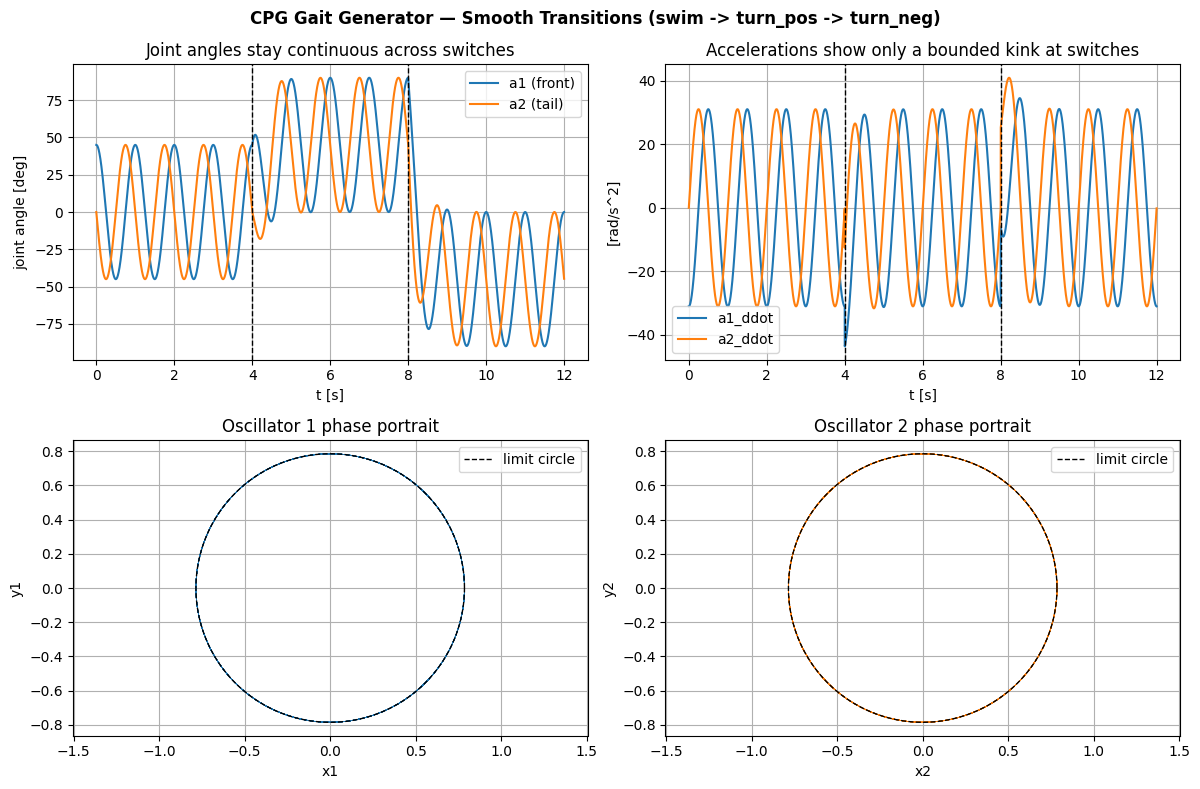

Done. Plot saved to cpg_core_demo.png


In [2]:
# %% [markdown]
# # CPG-Based Smooth Gait-Switching Core
#
# Inspired by JiChern/CPG — "Free Gait Transition and Stable Motion Generation
# Using CPG-based Locomotion Control" (Chen, Fan & Xu, *Nonlinear Dynamics*, 2024):
# https://github.com/JiChern/CPG
#
# The paper's improved diffusive CPG couples N Hopf-style oscillators with
# state vectors z_i = (x_i, y_i):
#
#     z_dot_i = F(z_i) + gamma_i * Perp_zi( R(theta_i) z_{i+1} - z_i )
#
# - F(z_i): intrinsic Hopf oscillator -> stable limit cycle of radius sqrt(mu)
#   at frequency omega.
# - R(theta_i): 2D rotation by the *desired phase lag* theta_i between
#   neighboring oscillators (this is the gait parameter).
# - Perp_zi(v) = v - (v . z_i / |z_i|^2) z_i: projects the coupling term
#   perpendicular to z_i, so coupling nudges PHASE only, leaving amplitude
#   (and hence joint amplitude) governed by F.
#
# Below this is specialised to N=2 oscillators driving the two swimmer joints
# (front angle a1, tail angle a2). Each oscillator also carries a slowly
# relaxing bias state b_i (first-order filter toward a target). The joint
# angle is a_i = b_i + x_i.
#
# Gait switching = changing the *targets* (theta_1, theta_2, b1_target,
# b2_target) of a running CPG. Because (x_i, y_i, b_i) are continuous ODE
# states, a_i and a_i_dot stay continuous across a switch -- only a_i_ddot has
# a (bounded) kink. This is the core improvement over a gait-library approach
# that swaps entire closed-form joint trajectories at cycle boundaries (which
# makes a_i itself jump).

# %%
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

# %% [markdown]
# ## 1. Symbolic CPG derivation (done once, then lambdified)

# %%
x1, y1, x2, y2, b1, b2 = sp.symbols("x1 y1 x2 y2 b1 b2", real=True)
th1, th2, g1, g2, mu1, mu2, om, alpha, kb, b1t, b2t = sp.symbols(
    "theta1 theta2 gamma1 gamma2 mu1 mu2 omega alpha k_b b1t b2t", real=True
)


def _hopf(x, y, mu):
    """Intrinsic Hopf oscillator: limit cycle radius sqrt(mu), freq omega."""
    r2 = x**2 + y**2
    return alpha * (mu - r2) * x - om * y, alpha * (mu - r2) * y + om * x


def _rot(theta, vx, vy):
    """2D rotation by desired phase lag theta."""
    return sp.cos(theta) * vx - sp.sin(theta) * vy, sp.sin(theta) * vx + sp.cos(theta) * vy


def _perp(zx, zy, vx, vy):
    """Project (vx,vy) perpendicular to (zx,zy) -> phase-only coupling."""
    eps = sp.Float(1e-6)
    dot = vx * zx + vy * zy
    nrm = zx**2 + zy**2 + eps
    return vx - dot / nrm * zx, vy - dot / nrm * zy


# Oscillator 1 (front joint) couples toward oscillator 2 rotated by theta1
Fx1, Fy1 = _hopf(x1, y1, mu1)
rx1, ry1 = _rot(th1, x2, y2)
px1, py1 = _perp(x1, y1, rx1 - x1, ry1 - y1)
x1dot = Fx1 + g1 * px1
y1dot = Fy1 + g1 * py1

# Oscillator 2 (tail joint) couples toward oscillator 1 rotated by theta2
Fx2, Fy2 = _hopf(x2, y2, mu2)
rx2, ry2 = _rot(th2, x1, y1)
px2, py2 = _perp(x2, y2, rx2 - x2, ry2 - y2)
x2dot = Fx2 + g2 * px2
y2dot = Fy2 + g2 * py2

# Bias states: first-order relaxation toward externally-set targets
b1dot = kb * (b1t - b1)
b2dot = kb * (b2t - b2)

_state = [x1, y1, x2, y2, b1, b2]
_zdot_expr = [x1dot, y1dot, x2dot, y2dot, b1dot, b2dot]

# Jacobian of the oscillator block (needed for analytic joint accelerations
# a_i_ddot = d/dt(a_i_dot) via the chain rule: zddot = J(z) @ zdot )
_J_osc = sp.Matrix([[sp.diff(e, v) for v in [x1, y1, x2, y2]] for e in [x1dot, y1dot, x2dot, y2dot]])

_params = [th1, th2, g1, g2, mu1, mu2, om, alpha, kb, b1t, b2t]
_zdot_fn = sp.lambdify(_state + _params, _zdot_expr, "numpy")
_Josc_fn = sp.lambdify(_state + _params, _J_osc, "numpy")

print("CPG symbolic derivation complete.")

# %% [markdown]
# ## 2. CPG gait generator class

# %%
W_GAIT = 2.0 * np.pi          # base oscillation frequency [rad/s]  (1 Hz)
T_GAIT = 2.0 * np.pi / W_GAIT  # nominal cycle period [s]
A_GAIT = np.pi / 4             # joint oscillation amplitude [rad]
MU_GAIT = A_GAIT**2             # Hopf limit-cycle radius^2 -> amplitude = sqrt(mu)
B_TURN = np.pi / 4              # body-curvature bias magnitude for turning [rad]

# Phase lag (theta) targets reproduce the original SWIM gait:
#   a1 = A*sin(wt), a2 = A*sin(wt + pi/2)  ->  tail leads front by +pi/2
THETA1_SWIM = -np.pi / 2
THETA2_SWIM = +np.pi / 2

# Named gait presets: (theta1, theta2, b1_target, b2_target)
GAITS = {
    "swim":     (THETA1_SWIM, THETA2_SWIM, 0.0, 0.0),
    "turn_pos": (THETA1_SWIM, THETA2_SWIM, +B_TURN, +B_TURN),
    "turn_neg": (THETA1_SWIM, THETA2_SWIM, -B_TURN, -B_TURN),
}


class CPGGaitGenerator:
    """
    2-oscillator diffusive Hopf CPG driving joint angles (a1, a2).

    State (6,): [x1, y1, x2, y2, b1, b2]
        a1 = b1 + x1,  a2 = b2 + x2

    Gait switching: call set_gait(name) or set_targets(...) at any time.
    The targets (theta1, theta2, b1_target, b2_target) are control inputs;
    the CPG state itself evolves continuously, so (a1, a2, a1_dot, a2_dot)
    never jump at a switch.
    """

    def __init__(self, omega=W_GAIT, mu=MU_GAIT, alpha=10.0, gamma=4.0, k_bias=4.0,
                 init_phase1=0.0, init_phase2=np.pi / 2):
        self.omega = omega
        self.mu1 = self.mu2 = mu
        self.alpha = alpha
        self.gamma = gamma
        self.k_bias = k_bias

        self.theta1, self.theta2, self.b1_target, self.b2_target = GAITS["swim"]

        r0 = np.sqrt(mu)
        self.state = np.array([
            r0 * np.cos(init_phase1), r0 * np.sin(init_phase1),
            r0 * np.cos(init_phase2), r0 * np.sin(init_phase2),
            0.0, 0.0,
        ])

    # -- gait switching -----------------------------------------------------
    def set_gait(self, name):
        self.theta1, self.theta2, self.b1_target, self.b2_target = GAITS[name]

    def set_targets(self, theta1=None, theta2=None, b1_target=None, b2_target=None):
        if theta1 is not None: self.theta1 = theta1
        if theta2 is not None: self.theta2 = theta2
        if b1_target is not None: self.b1_target = b1_target
        if b2_target is not None: self.b2_target = b2_target

    # -- core dynamics --------------------------------------------------------
    def _params(self):
        return [self.theta1, self.theta2, self.gamma, self.gamma,
                self.mu1, self.mu2, self.omega, self.alpha, self.k_bias,
                self.b1_target, self.b2_target]

    def derivative(self, state=None):
        """6-vector state derivative (for embedding in a larger ODE)."""
        s = self.state if state is None else state
        return np.asarray(_zdot_fn(*s, *self._params()), dtype=float)

    def joint_kinematics(self, state=None):
        """Return (a1, a2, a1_dot, a2_dot, a1_ddot, a2_ddot)."""
        s = self.state if state is None else state
        zd = self.derivative(s)
        J = np.asarray(_Josc_fn(*s, *self._params()), dtype=float)
        zdd_osc = J @ zd[:4]
        a1, a2 = s[4] + s[0], s[5] + s[2]
        a1d, a2d = zd[4] + zd[0], zd[5] + zd[2]
        a1dd = -self.k_bias * zd[4] + zdd_osc[0]
        a2dd = -self.k_bias * zd[5] + zdd_osc[2]
        return a1, a2, a1d, a2d, a1dd, a2dd

    # -- standalone integration (RK4) -----------------------------------------
    def step(self, dt):
        """Advance the internal CPG state by dt using RK4 (standalone use)."""
        k1 = self.derivative(self.state)
        k2 = self.derivative(self.state + 0.5 * dt * k1)
        k3 = self.derivative(self.state + 0.5 * dt * k2)
        k4 = self.derivative(self.state + dt * k3)
        self.state = self.state + dt / 6.0 * (k1 + 2 * k2 + 2 * k3 + k4)


# %% [markdown]
# ## 3. Demo — smooth gait transition (swim -> turn_pos -> swim)
#
# Reproduces the spirit of the repo's `gait_transition_curves.png`: the
# oscillator phase portraits stay on (near) the limit circle throughout,
# while the joint-angle offsets shift smoothly between gaits.

# %%
if __name__ == "__main__":
    cpg = CPGGaitGenerator()

    dt = 0.001
    t_end = 12.0
    ts = np.arange(0.0, t_end, dt)

    a1_h = np.zeros_like(ts); a2_h = np.zeros_like(ts)
    a1d_h = np.zeros_like(ts); a2d_h = np.zeros_like(ts)
    a1dd_h = np.zeros_like(ts); a2dd_h = np.zeros_like(ts)
    x1_h = np.zeros_like(ts); y1_h = np.zeros_like(ts)
    x2_h = np.zeros_like(ts); y2_h = np.zeros_like(ts)
    gait_h = []

    for i, tv in enumerate(ts):
        if tv < 4.0:
            cpg.set_gait("swim")
        elif tv < 8.0:
            cpg.set_gait("turn_pos")
        else:
            cpg.set_gait("turn_neg")

        a1, a2, a1d, a2d, a1dd, a2dd = cpg.joint_kinematics()
        a1_h[i], a2_h[i] = a1, a2
        a1d_h[i], a2d_h[i] = a1d, a2d
        a1dd_h[i], a2dd_h[i] = a1dd, a2dd
        x1_h[i], y1_h[i], x2_h[i], y2_h[i] = cpg.state[0], cpg.state[1], cpg.state[2], cpg.state[3]
        gait_h.append((cpg.b1_target, cpg.b2_target))

        cpg.step(dt)

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle("CPG Gait Generator — Smooth Transitions (swim -> turn_pos -> turn_neg)",
                  fontsize=12, fontweight="bold")

    ax = axes[0, 0]
    ax.plot(ts, np.degrees(a1_h), label="a1 (front)")
    ax.plot(ts, np.degrees(a2_h), label="a2 (tail)")
    for tt in (4.0, 8.0):
        ax.axvline(tt, color="k", ls="--", lw=1)
    ax.set_xlabel("t [s]"); ax.set_ylabel("joint angle [deg]")
    ax.set_title("Joint angles stay continuous across switches")
    ax.legend(); ax.grid(True)

    ax = axes[0, 1]
    ax.plot(ts, a1dd_h, label="a1_ddot")
    ax.plot(ts, a2dd_h, label="a2_ddot")
    for tt in (4.0, 8.0):
        ax.axvline(tt, color="k", ls="--", lw=1)
    ax.set_xlabel("t [s]"); ax.set_ylabel("[rad/s^2]")
    ax.set_title("Accelerations show only a bounded kink at switches")
    ax.legend(); ax.grid(True)

    ax = axes[1, 0]
    ax.plot(x1_h, y1_h, lw=0.5)
    th = np.linspace(0, 2 * np.pi, 200)
    ax.plot(np.sqrt(MU_GAIT) * np.cos(th), np.sqrt(MU_GAIT) * np.sin(th), 'k--', lw=1, label="limit circle")
    ax.set_xlabel("x1"); ax.set_ylabel("y1")
    ax.set_title("Oscillator 1 phase portrait")
    ax.axis("equal"); ax.legend(); ax.grid(True)

    ax = axes[1, 1]
    ax.plot(x2_h, y2_h, lw=0.5, color="tab:orange")
    ax.plot(np.sqrt(MU_GAIT) * np.cos(th), np.sqrt(MU_GAIT) * np.sin(th), 'k--', lw=1, label="limit circle")
    ax.set_xlabel("x2"); ax.set_ylabel("y2")
    ax.set_title("Oscillator 2 phase portrait")
    ax.axis("equal"); ax.legend(); ax.grid(True)

    plt.tight_layout()
    plt.savefig("cpg_core_demo.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Done. Plot saved to cpg_core_demo.png")


CPG symbolic derivation complete.
Body dynamics symbolic derivation complete.
Gait turning diagnostic (3 cycles from rest, no flow)
  swim      : Delta theta = +8.28 deg (per 3 cycles)
  turn_pos  : Delta theta = +11.04 deg (per 3 cycles)
  turn_neg  : Delta theta = +6.19 deg (per 3 cycles)

  -> GAIT_CW  = 'turn_neg'   bias = (-0.7853981633974483, -0.7853981633974483)
  -> GAIT_CCW = 'turn_pos'   bias = (0.7853981633974483, 0.7853981633974483)

--- OLD (discrete gait-library) controller ---
Final y: A=-0.0624  B=1.9244  C=-0.0675

--- NEW (CPG smooth) controller ---
Final y: A=-0.0761  B=1.8801  C=-0.1147


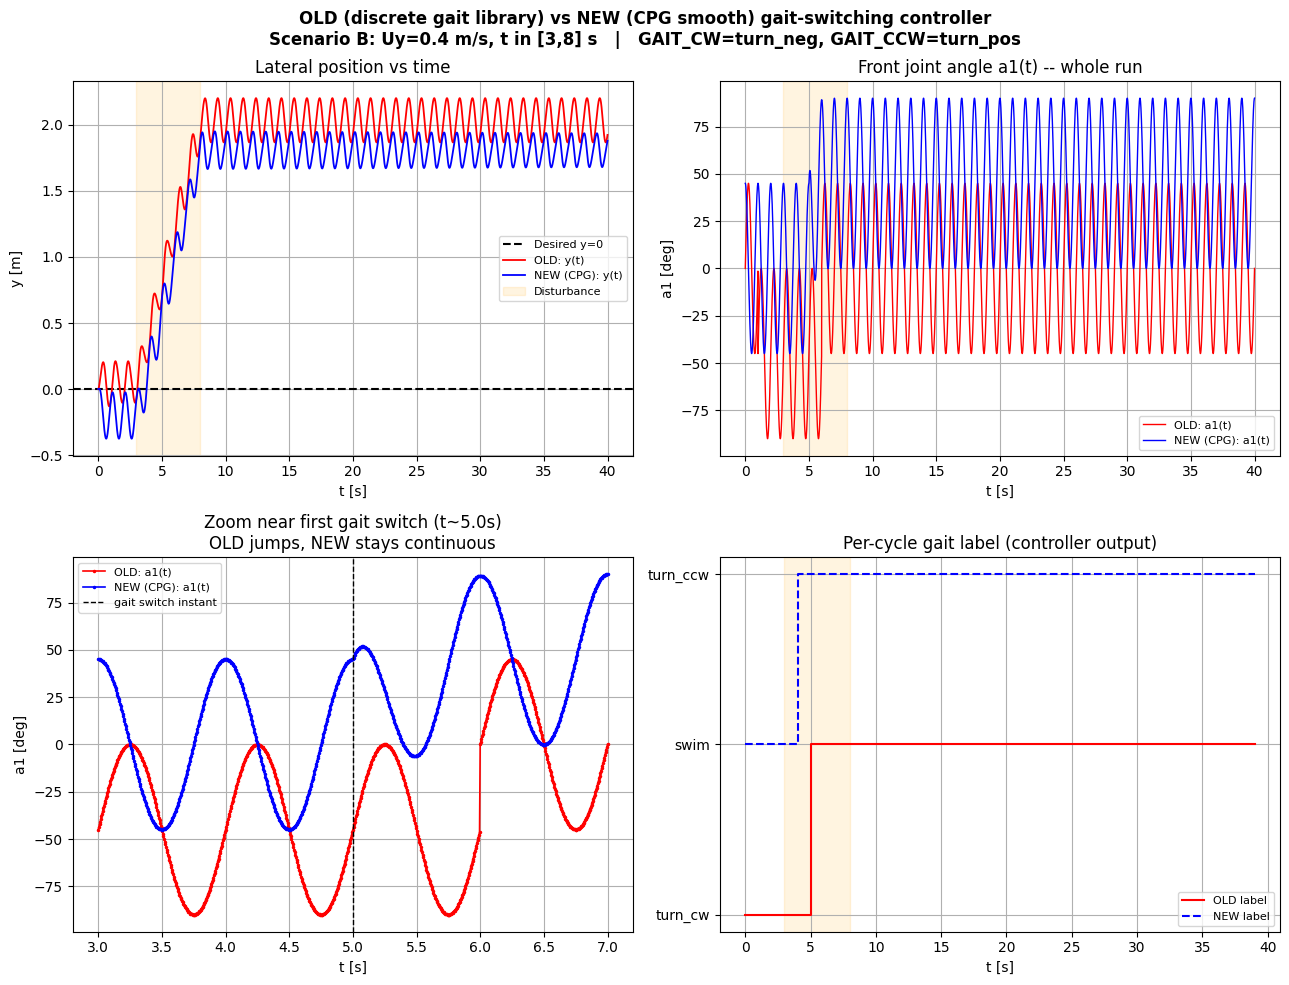


Done. Plot saved to cpg_vs_discrete_gait_switching.png


In [3]:
# %% [markdown]
# # CPG-Based Gait-Switching Controller for the 3-Link Swimmer
#
# This builds on `cpg_core.py` (a 2-oscillator diffusive Hopf CPG, inspired by
# JiChern/CPG: https://github.com/JiChern/CPG) and plugs it into the 3-link
# swimmer body dynamics from `path_tracking_gait_switching.py`.
#
# **Old controller** (path_tracking_gait_switching.py): the cascade controller
# picks a gait *name* once per cycle and the joint trajectories a1(t), a2(t)
# are recomputed from a fresh closed-form sin() with a different bias/phase --
# a1(t) JUMPS at the cycle boundary when the gait changes.
#
# **New controller** (this file): the cascade controller instead sets CPG
# *targets* (bias_1, bias_2) once per cycle. The CPG's internal state (which
# includes first-order bias filters) evolves continuously, so a1(t), a2(t),
# a1_dot(t), a2_dot(t) never jump -- only the accelerations show a bounded
# kink. Run this notebook to compare both controllers side by side.
#
# Run `cpg_core.py` first (or make sure it's in the same folder) -- this file
# imports the CPG class from it.

# %%
import numpy as np
import sympy as sp
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from cpg_core import CPGGaitGenerator, GAITS, W_GAIT, T_GAIT, A_GAIT, B_TURN

PHI_G = np.pi / 2  # tail-front phase offset (matches CPG swim phase lag)

# %% [markdown]
# ## 1. Body dynamics (3-link swimmer Lagrangian)
#
# Identical derivation to `path_tracking_gait_switching.py` -- repeated here
# so this file is self-contained.

# %%
t = sp.symbols("t", real=True)
l, m, I_link, c = sp.symbols("l m I c", positive=True, real=True)
U_flow, U_flow_y = sp.symbols("U_flow U_flow_y", real=True)

x = sp.Function("x")(t)
y = sp.Function("y")(t)
theta = sp.Function("theta")(t)
a1 = sp.Function("a1")(t)
a2 = sp.Function("a2")(t)

q = [x, y, theta, a1, a2]
q_dt = [sp.diff(v, t) for v in q]
n = 5


def R_z(ang):
    return sp.Matrix([[sp.cos(ang), -sp.sin(ang), 0],
                       [sp.sin(ang),  sp.cos(ang), 0],
                       [0,            0,           1]])


def make_T(R, p):
    return sp.Matrix([
        [R[0, 0], R[0, 1], R[0, 2], p[0, 0]],
        [R[1, 0], R[1, 1], R[1, 2], p[1, 0]],
        [R[2, 0], R[2, 1], R[2, 2], p[2, 0]],
        [0,       0,       0,       1],
    ])


T_base = make_T(R_z(theta), sp.Matrix([[x], [y], [0]]))
T_front = (T_base
           @ make_T(sp.eye(3), sp.Matrix([[-l / 2], [0], [0]]))
           @ make_T(R_z(a1), sp.Matrix([[0], [0], [0]]))
           @ make_T(sp.eye(3), sp.Matrix([[-l / 2], [0], [0]])))
T_tail = (T_base
          @ make_T(sp.eye(3), sp.Matrix([[l / 2], [0], [0]]))
          @ make_T(R_z(a2), sp.Matrix([[0], [0], [0]]))
          @ make_T(sp.eye(3), sp.Matrix([[l / 2], [0], [0]])))

r_base = sp.Matrix([T_base[0, 3], T_base[1, 3]])
r_front = sp.simplify(sp.Matrix([T_front[0, 3], T_front[1, 3]]))
r_tail = sp.simplify(sp.Matrix([T_tail[0, 3], T_tail[1, 3]]))

J_base = r_base.jacobian(q)
J_front = sp.simplify(r_front.jacobian(q))
J_tail = sp.simplify(r_tail.jacobian(q))

qd = sp.Matrix(q_dt)


def link_KE(J_v, omega_sym):
    v = J_v @ qd
    return sp.Rational(1, 2) * m * (v.T @ v)[0, 0] + sp.Rational(1, 2) * I_link * omega_sym**2


T_kin = sp.expand(
    link_KE(J_base, q_dt[2])
    + link_KE(J_front, q_dt[2] + q_dt[3])
    + link_KE(J_tail, q_dt[2] + q_dt[4])
)

M_mat = sp.simplify(sp.Matrix([
    [sp.diff(sp.diff(T_kin, q_dt[i]), q_dt[j]) for j in range(n)]
    for i in range(n)
]))

q_ddt_syms = sp.symbols("xdd ydd thdd a1dd a2dd")
h_vec = sp.Matrix.zeros(n, 1)
for i in range(n):
    dT_i = sp.diff(T_kin, q_dt[i])
    ddt_i = sum(
        sp.diff(dT_i, q[j]) * q_dt[j] + sp.diff(dT_i, q_dt[j]) * q_ddt_syms[j]
        for j in range(n)
    )
    h_vec[i] = sp.simplify(ddt_i.subs(dict(zip(q_ddt_syms, [0] * n))) - sp.diff(T_kin, q[i]))


def flow_field(px, py):
    return sp.Matrix([U_flow, U_flow_y])


def generalized_drag_force(J_v, r_i):
    vf_i = flow_field(r_i[0], r_i[1])
    vrel = J_v @ qd - vf_i
    return J_v.T @ (-c * vrel)


Q_flow = sp.simplify(
    generalized_drag_force(J_base, r_base)
    + generalized_drag_force(J_front, r_front)
    + generalized_drag_force(J_tail, r_tail)
)

params_sym = [l, m, I_link, c, U_flow, U_flow_y]
M_fn = sp.lambdify([q, params_sym], M_mat, "numpy")
h_fn = sp.lambdify([q, q_dt, params_sym], h_vec, "numpy")
Qf_fn = sp.lambdify([q, q_dt, params_sym], Q_flow, "numpy")

print("Body dynamics symbolic derivation complete.")

# %% [markdown]
# ## 2. Physical parameters & disturbance helper

# %%
l_val = 1.0
m_val = 0.1
I_val = m_val * l_val**2 / 12.0
c_val = 1.0


def make_params(Ux=0.0, Uy=0.0):
    return [l_val, m_val, I_val, c_val, Ux, Uy]


def get_disturbance(tv, disturbances):
    for t0, t1, Ux, Uy in disturbances:
        if t0 <= tv < t1:
            return Ux, Uy
    return 0.0, 0.0


# %% [markdown]
# ## 3. NEW controller: CPG-driven dynamics (12-state system)
#
# State = [x, y, theta, xd, yd, thd,  x1, y1, x2, y2, b1, b2]
#                body (6)                   CPG (6)

# %%
def dynamics_cpg(tv, state, cpg, Ux, Uy):
    body = state[0:6]
    cpg_state = state[6:12]
    xv, yv, thv, xd, yd, thd = body

    a1v, a2v, a1d, a2d, a1dd, a2dd = cpg.joint_kinematics(cpg_state)

    p_vals = make_params(Ux=Ux, Uy=Uy)
    qc = [xv, yv, thv, a1v, a2v]
    qdc = [xd, yd, thd, a1d, a2d]
    M_ = np.array(M_fn(qc, p_vals), dtype=float)
    h_ = np.array(h_fn(qc, qdc, p_vals), dtype=float).flatten()
    Qf_ = np.array(Qf_fn(qc, qdc, p_vals), dtype=float).flatten()

    rhs = Qf_[0:3] - h_[0:3] - M_[0:3, 3:5] @ np.array([a1dd, a2dd])
    body_acc = np.linalg.solve(M_[0:3, 0:3], rhs)

    cpg_dot = cpg.derivative(cpg_state)
    return [xd, yd, thd, *body_acc, *cpg_dot]


# %% [markdown]
# ## 4. OLD controller: gait-library dynamics (for comparison)
#
# Same gait library / dynamics as `path_tracking_gait_switching.py`.

# %%
GAIT_PARAMS = {
    'swim':     (0.0, 0.0),
    'turn_pos': (+B_TURN, +B_TURN),
    'turn_neg': (-B_TURN, -B_TURN),
}


def gait_kinematics_old(tv, gait_name):
    d1, d2 = GAIT_PARAMS[gait_name]
    a1v = d1 + A_GAIT * np.sin(W_GAIT * tv)
    a2v = d2 + A_GAIT * np.sin(W_GAIT * tv + PHI_G)
    a1d = A_GAIT * W_GAIT * np.cos(W_GAIT * tv)
    a2d = A_GAIT * W_GAIT * np.cos(W_GAIT * tv + PHI_G)
    a1dd = -A_GAIT * W_GAIT**2 * np.sin(W_GAIT * tv)
    a2dd = -A_GAIT * W_GAIT**2 * np.sin(W_GAIT * tv + PHI_G)
    return a1v, a2v, a1d, a2d, a1dd, a2dd


def dynamics_old(tv, state, gait_name, Ux, Uy):
    xv, yv, thv, xd, yd, thd = state
    p_vals = make_params(Ux=Ux, Uy=Uy)
    a1v, a2v, a1d, a2d, a1dd, a2dd = gait_kinematics_old(tv, gait_name)
    qc = [xv, yv, thv, a1v, a2v]
    qdc = [xd, yd, thd, a1d, a2d]
    M_ = np.array(M_fn(qc, p_vals), dtype=float)
    h_ = np.array(h_fn(qc, qdc, p_vals), dtype=float).flatten()
    Qf_ = np.array(Qf_fn(qc, qdc, p_vals), dtype=float).flatten()
    rhs = Qf_[0:3] - h_[0:3] - M_[0:3, 3:5] @ np.array([a1dd, a2dd])
    q_ddot_pas = np.linalg.solve(M_[0:3, 0:3], rhs)
    return [xd, yd, thd, *q_ddot_pas]


# %% [markdown]
# ## 5. Shared cascade controller (heading -> gait label)
#
# Same control law as the original file. The only thing that differs between
# old/new is how the resulting label is *realized* in the joint trajectories.

# %%
K_POS = 0.20
PSI_MAX = np.radians(15)
TURN_THRESH = np.radians(5)


def desired_heading(y_end):
    return float(np.clip(K_POS * y_end, -PSI_MAX, PSI_MAX))


def cascade_controller(y_end, th_avg):
    psi_d = desired_heading(y_end)
    e_psi = (th_avg - psi_d + np.pi) % (2.0 * np.pi) - np.pi
    if e_psi > +TURN_THRESH:
        return 'turn_cw', psi_d, e_psi
    elif e_psi < -TURN_THRESH:
        return 'turn_ccw', psi_d, e_psi
    else:
        return 'swim', psi_d, e_psi


# %% [markdown]
# ## 6. Gait-turning diagnostic -> assign CW/CCW bias sign
#
# Runs 3 cycles of `turn_pos`/`turn_neg` (old dynamics, from rest) and measures
# net Delta-theta. This is a pure body-dynamics property, so the same
# CW/CCW assignment applies whether the bias is realized via the old gait
# library or the new CPG.

# %%
print("Gait turning diagnostic (3 cycles from rest, no flow)")
_dtheta = {}
for _gname in ['swim', 'turn_pos', 'turn_neg']:
    _sv = solve_ivp(
        lambda tv, s, g=_gname: dynamics_old(tv, s, g, 0.0, 0.0),
        [0.0, 3 * T_GAIT], [0.0] * 6,
        t_eval=np.linspace(0, 3 * T_GAIT, 300), rtol=1e-8, atol=1e-8
    )
    _dtheta[_gname] = _sv.y[2, -1]
    print(f"  {_gname:10s}: Delta theta = {np.degrees(_dtheta[_gname]):+.2f} deg (per 3 cycles)")

if _dtheta['turn_pos'] < _dtheta['turn_neg']:
    GAIT_CW, GAIT_CCW = 'turn_pos', 'turn_neg'
    BIAS_CW, BIAS_CCW = (+B_TURN, +B_TURN), (-B_TURN, -B_TURN)
else:
    GAIT_CW, GAIT_CCW = 'turn_neg', 'turn_pos'
    BIAS_CW, BIAS_CCW = (-B_TURN, -B_TURN), (+B_TURN, +B_TURN)

print(f"\n  -> GAIT_CW  = '{GAIT_CW}'   bias = {BIAS_CW}")
print(f"  -> GAIT_CCW = '{GAIT_CCW}'   bias = {BIAS_CCW}")


def resolve_gait_old(label):
    if label == 'turn_cw':  return GAIT_CW
    if label == 'turn_ccw': return GAIT_CCW
    return 'swim'


def resolve_bias_new(label):
    if label == 'turn_cw':  return BIAS_CW
    if label == 'turn_ccw': return BIAS_CCW
    return (0.0, 0.0)


# %% [markdown]
# ## 7. Cycle-based simulators
#
# Both simulators run one gait cycle at a time, read end-of-cycle (y, theta),
# run the shared cascade controller, and update the gait for the next cycle.
# - OLD: switches `gait_now` (a discrete label -> new closed-form a1(t),a2(t)).
# - NEW: calls `cpg.set_targets(b1_target=, b2_target=)` -- the CPG state
#   (already mid-trajectory) relaxes toward the new bias smoothly.

# %%
def simulate_old(t_end, s0, disturbances, pts_per_cycle=200):
    state = np.array(s0, dtype=float)
    t_now, gait_now = 0.0, 'swim'
    t_segs, y_segs, a1_segs, log = [], [], [], []

    while t_now < t_end - 1e-10:
        t_next = min(t_now + T_GAIT, t_end)
        t_seg = np.linspace(t_now, t_next, pts_per_cycle)
        g_hold = gait_now

        sol = solve_ivp(
            lambda tv, s: dynamics_old(tv, s, g_hold, *get_disturbance(tv, disturbances)),
            [t_now, t_next], state, t_eval=t_seg, rtol=1e-8, atol=1e-8, method='RK45'
        )

        t_segs.append(sol.t[:-1])
        y_segs.append(sol.y[:, :-1])
        a1_segs.append(np.array([gait_kinematics_old(tv, g_hold)[0] for tv in sol.t[:-1]]))

        state = sol.y[:, -1]
        t_now = t_next

        y_end = state[1]
        th_avg = float(np.angle(np.mean(np.exp(1j * sol.y[2]))))
        label, psi_d, e_psi = cascade_controller(y_end, th_avg)
        gait_now = resolve_gait_old(label)

        log.append({'t': t_now, 'y_end': y_end, 'th_avg': th_avg,
                     'psi_d': psi_d, 'e_psi': e_psi, 'label': label, 'gait': gait_now})

    t_segs.append(np.array([t_now]))
    y_segs.append(state.reshape(6, 1))
    a1_segs.append(np.array([gait_kinematics_old(t_now, gait_now)[0]]))

    return (np.concatenate(t_segs), np.concatenate(y_segs, axis=1),
            np.concatenate(a1_segs), log)


def simulate_cpg(t_end, s0, disturbances, pts_per_cycle=200):
    cpg = CPGGaitGenerator()
    state = np.concatenate([np.asarray(s0, dtype=float), cpg.state])
    t_now = 0.0
    t_segs, y_segs, log = [], [], []

    while t_now < t_end - 1e-10:
        t_next = min(t_now + T_GAIT, t_end)
        t_seg = np.linspace(t_now, t_next, pts_per_cycle)

        sol = solve_ivp(
            lambda tv, s: dynamics_cpg(tv, s, cpg, *get_disturbance(tv, disturbances)),
            [t_now, t_next], state, t_eval=t_seg, rtol=1e-8, atol=1e-8, method='RK45'
        )

        t_segs.append(sol.t[:-1])
        y_segs.append(sol.y[:, :-1])

        state = sol.y[:, -1]
        cpg.state = state[6:12]
        t_now = t_next

        y_end = state[1]
        th_avg = float(np.angle(np.mean(np.exp(1j * sol.y[2]))))
        label, psi_d, e_psi = cascade_controller(y_end, th_avg)
        b1_t, b2_t = resolve_bias_new(label)
        cpg.set_targets(b1_target=b1_t, b2_target=b2_t)

        log.append({'t': t_now, 'y_end': y_end, 'th_avg': th_avg,
                     'psi_d': psi_d, 'e_psi': e_psi, 'label': label,
                     'b1_target': b1_t, 'b2_target': b2_t})

    t_segs.append(np.array([t_now]))
    y_segs.append(state.reshape(12, 1))

    t_arr = np.concatenate(t_segs)
    y_arr = np.concatenate(y_segs, axis=1)
    a1_arr = y_arr[10, :] + y_arr[6, :]   # a1 = b1 + x1
    return t_arr, y_arr, a1_arr, log


# %% [markdown]
# ## 8. Run scenarios
#
# Same scenarios as the original file: A) no disturbance, B) one cross-flow
# pulse, C) two opposing pulses. Run with both controllers.

# %%
T_END = 40.0
s0 = [0.0] * 6
dist_B = [(3.0, 8.0, 0.0, 0.4)]
dist_C = [(3.0, 8.0, 0.0, 0.4), (22.0, 27.0, 0.0, -0.4)]

print("\n--- OLD (discrete gait-library) controller ---")
tA_o, yA_o, a1A_o, logA_o = simulate_old(T_END, s0, [])
tB_o, yB_o, a1B_o, logB_o = simulate_old(T_END, s0, dist_B)
tC_o, yC_o, a1C_o, logC_o = simulate_old(T_END, s0, dist_C)
print(f"Final y: A={yA_o[1,-1]:.4f}  B={yB_o[1,-1]:.4f}  C={yC_o[1,-1]:.4f}")

print("\n--- NEW (CPG smooth) controller ---")
tA_n, yA_n, a1A_n, logA_n = simulate_cpg(T_END, s0, [])
tB_n, yB_n, a1B_n, logB_n = simulate_cpg(T_END, s0, dist_B)
tC_n, yC_n, a1C_n, logC_n = simulate_cpg(T_END, s0, dist_C)
print(f"Final y: A={yA_n[1,-1]:.4f}  B={yB_n[1,-1]:.4f}  C={yC_n[1,-1]:.4f}")

# %% [markdown]
# ## 9. Compare: trajectories + gait switching + joint-angle continuity

# %%
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("OLD (discrete gait library) vs NEW (CPG smooth) gait-switching controller\n"
              f"Scenario B: Uy=0.4 m/s, t in [3,8] s   |   GAIT_CW={GAIT_CW}, GAIT_CCW={GAIT_CCW}",
              fontsize=12, fontweight="bold")

ax = axes[0, 0]
ax.axhline(0, color='k', ls='--', lw=1.5, label='Desired y=0')
ax.plot(tB_o, yB_o[1], 'r-', lw=1.3, label='OLD: y(t)')
ax.plot(tB_n, yB_n[1], 'b-', lw=1.3, label='NEW (CPG): y(t)')
for t0, t1, _, _ in dist_B:
    ax.axvspan(t0, t1, alpha=0.12, color='orange', label='Disturbance')
ax.set_xlabel('t [s]'); ax.set_ylabel('y [m]')
ax.set_title('Lateral position vs time')
ax.legend(fontsize=8); ax.grid(True)

ax = axes[0, 1]
ax.plot(tB_o, np.degrees(a1B_o), 'r-', lw=1.0, label='OLD: a1(t)')
ax.plot(tB_n, np.degrees(a1B_n), 'b-', lw=1.0, label='NEW (CPG): a1(t)')
for t0, t1, _, _ in dist_B:
    ax.axvspan(t0, t1, alpha=0.12, color='orange')
ax.set_xlabel('t [s]'); ax.set_ylabel('a1 [deg]')
ax.set_title('Front joint angle a1(t) -- whole run')
ax.legend(fontsize=8); ax.grid(True)

# zoom near the first switch out of 'swim'
switch_t = next((d['t'] for d in logB_n if d['label'] != 'swim'), T_GAIT)
zoom_lo, zoom_hi = max(0, switch_t - 2 * T_GAIT), switch_t + 2 * T_GAIT

ax = axes[1, 0]
mo = (tB_o >= zoom_lo) & (tB_o <= zoom_hi)
mn = (tB_n >= zoom_lo) & (tB_n <= zoom_hi)
ax.plot(tB_o[mo], np.degrees(a1B_o[mo]), 'r.-', lw=1.2, ms=3, label='OLD: a1(t)')
ax.plot(tB_n[mn], np.degrees(a1B_n[mn]), 'b.-', lw=1.2, ms=3, label='NEW (CPG): a1(t)')
ax.axvline(switch_t, color='k', ls='--', lw=1, label='gait switch instant')
ax.set_xlabel('t [s]'); ax.set_ylabel('a1 [deg]')
ax.set_title(f'Zoom near first gait switch (t~{switch_t:.1f}s)\nOLD jumps, NEW stays continuous')
ax.legend(fontsize=8); ax.grid(True)

ax = axes[1, 1]
labels_o = [d['label'] for d in logB_o]
labels_n = [d['label'] for d in logB_n]
times_o = [d['t'] - T_GAIT for d in logB_o]
times_n = [d['t'] - T_GAIT for d in logB_n]
code = {'swim': 0, 'turn_cw': -1, 'turn_ccw': 1}
ax.step(times_o, [code[l] for l in labels_o], 'r-', where='post', lw=1.5, label='OLD label')
ax.step(times_n, [code[l] for l in labels_n], 'b--', where='post', lw=1.5, label='NEW label')
for t0, t1, _, _ in dist_B:
    ax.axvspan(t0, t1, alpha=0.12, color='orange')
ax.set_yticks([-1, 0, 1]); ax.set_yticklabels(['turn_cw', 'swim', 'turn_ccw'])
ax.set_xlabel('t [s]'); ax.set_title('Per-cycle gait label (controller output)')
ax.legend(fontsize=8); ax.grid(True)

plt.tight_layout()
plt.savefig("cpg_vs_discrete_gait_switching.png", dpi=120, bbox_inches="tight")
plt.show()
print("\nDone. Plot saved to cpg_vs_discrete_gait_switching.png")
